# Imports

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Análise de Dados — Doença de Alzheimer

## Introdução

Este notebook tem como objetivo explorar e analisar um conjunto de dados clínicos contendo informações detalhadas de **2.149 pacientes**, com foco na identificação de fatores associados ao diagnóstico da **Doença de Alzheimer**.

O dataset reúne uma ampla variedade de variáveis, permitindo uma análise multidimensional que abrange aspectos **demográficos, comportamentais, clínicos e cognitivos**. Essa diversidade de informações possibilita investigações aprofundadas sobre padrões, correlações e potenciais preditores da doença.

## Descrição do Dataset

Cada paciente é identificado por um ID único (variando de 4751 a 6900) e possui informações organizadas nas seguintes categorias:

### Informações Demográficas

- Idade (`Age`): idade do paciente, variando de **60 a 90 anos**.  
- Gênero (`Gender`): sexo do paciente  
  - `0`: Masculino  
  - `1`: Feminino  

- Etnia (`Ethnicity`): grupo étnico do paciente  
  - `0`: Caucasiano  
  - `1`: Afro-americano  
  - `2`: Asiático  
  - `3`: Outros  

- Nível de escolaridade (`EducationLevel`): grau de instrução  
  - `0`: Nenhuma escolaridade  
  - `1`: Ensino médio  
  - `2`: Bacharelado  
  - `3`: Pós-graduação ou superior  

---

### Estilo de Vida

- Índice de Massa Corporal (`BMI`): medida do peso em relação à altura, variando de **15 a 40**.  

- Tabagismo (`Smoking`): indica se o paciente fuma  
  - `0`: Não  
  - `1`: Sim  

- Consumo de álcool (`AlcoholConsumption`): consumo semanal em unidades, variando de **0 a 20**.  

- Atividade física (`PhysicalActivity`): número de horas semanais de exercício, variando de **0 a 10 horas**.  

- Qualidade da dieta (`DietQuality`): score da alimentação, variando de **0 a 10**  
  - Valores maiores indicam melhor qualidade alimentar  

- Qualidade do sono (`SleepQuality`): score do sono, variando de **4 a 10**  
  - Valores maiores indicam melhor qualidade do sono  

---

### Histórico Médico

- Histórico familiar de Alzheimer (`FamilyHistoryAlzheimers`)  
  - `0`: Não  
  - `1`: Sim  

- Doença cardiovascular (`CardiovascularDisease`)  
  - `0`: Não  
  - `1`: Sim  

- Diabetes (`Diabetes`)  
  - `0`: Não  
  - `1`: Sim  

- Depressão (`Depression`)  
  - `0`: Não  
  - `1`: Sim  

- Lesão na cabeça (`HeadInjury`)  
  - `0`: Não  
  - `1`: Sim  

- Hipertensão (`Hypertension`)  
  - `0`: Não  
  - `1`: Sim  

---

### Medidas Clínicas

- Pressão sistólica (`SystolicBP`): pressão arterial máxima, variando de **90 a 180 mmHg**.  

- Pressão diastólica (`DiastolicBP`): pressão arterial mínima, variando de **60 a 120 mmHg**.  

- Colesterol total (`CholesterolTotal`): níveis totais de colesterol, variando de **150 a 300 mg/dL**.  

- Colesterol LDL (`CholesterolLDL`): colesterol “ruim”, variando de **50 a 200 mg/dL**.  

- Colesterol HDL (`CholesterolHDL`): colesterol “bom”, variando de **20 a 100 mg/dL**.  

- Triglicerídeos (`CholesterolTriglycerides`): níveis de triglicerídeos, variando de **50 a 400 mg/dL**.  

---

### Avaliações Cognitivas e Funcionais

- MMSE (`MMSE`): Mini-Mental State Examination  
  - Varia de **0 a 30**  
  - Valores menores indicam **maior comprometimento cognitivo**  

- Avaliação funcional (`FunctionalAssessment`)  
  - Varia de **0 a 10**  
  - Valores menores indicam **maior incapacidade funcional**  

- Queixas de memória (`MemoryComplaints`)  
  - `0`: Não  
  - `1`: Sim  

- Problemas comportamentais (`BehavioralProblems`)  
  - `0`: Não  
  - `1`: Sim  

- Atividades de vida diária (`ADL`)  
  - Varia de **0 a 10**  
  - Valores menores indicam **maior dependência nas atividades diárias**  

---

### Sintomas

- Confusão (`Confusion`)  
  - `0`: Não  
  - `1`: Sim  

- Desorientação (`Disorientation`)  
  - `0`: Não  
  - `1`: Sim  

- Mudanças de personalidade (`PersonalityChanges`)  
  - `0`: Não  
  - `1`: Sim  

- Dificuldade em completar tarefas (`DifficultyCompletingTasks`)  
  - `0`: Não  
  - `1`: Sim  

- Esquecimento (`Forgetfulness`)  
  - `0`: Não  
  - `1`: Sim  

---

### Diagnóstico

- Diagnóstico de Alzheimer (`Diagnosis`)  
  - `0`: Não possui Alzheimer  
  - `1`: Possui Alzheimer  

---

## Objetivo da Análise

A partir deste dataset, pretende-se:

**Definir objetivos**

## Observações

- A coluna `DoctorInCharge` contém dados confidenciais e não será utilizada na análise.
- As variáveis categóricas são codificadas numericamente, exigindo interpretação adequada durante a análise.

# Parte I - Análise inicial dos dados

In [82]:
# Importando os dados
df = pd.read_csv('../data/alzheimers_disease_data.csv')
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [83]:
# Analisando a natureza dos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [84]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [85]:
# Analisando a presença de valores nulos nas colunas que o info não mostrou
df.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

In [86]:
# Analisando a presença de valores duplicados
df.duplicated().sum()

0

In [87]:
# Dropando as colunas 'PatientID' e 'DoctorInCharge' por não serem relevantes para a análise
df.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True)
df.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


In [ ]:
#DataFrame numerico para usar em correlação
df_numeric = pd.read_csv('../data/alzheimers_disease_data.csv')

df_numeric.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True)
df_numeric.head()

In [91]:
# Criando um DataFrame para visualização com as colunas categoricas
df_visual = df_numeric.copy()

df_visual['Diagnosis'] = df_visual['Diagnosis'].map({0: 'Sem Alzheimer', 1: 'Com Alzheimer'})
df_visual['Hypertension'] = df_visual['Hypertension'].map({0: 'Não hipertenso', 1: 'hipertenso'})
df_visual['Diabetes'] = df_visual['Diabetes'].map({0: 'Sem diabetes', 1: 'Diabético'})
df_visual['Gender'] = df_visual['Gender'].map({0: 'Feminino', 1: 'Masculino'})


## Análise Inicial dos Dados

Após uma análise exploratória inicial do dataset, foi possível verificar que os dados já se encontram bem estruturados e tratados, não apresentando problemas comuns como **valores duplicados** ou **dados faltantes (missing values)**.

Além disso, foi realizada uma etapa de limpeza para remover colunas consideradas irrelevantes para a análise. As seguintes variáveis foram descartadas:

- `PatientID`: identificador único dos pacientes, sem valor analítico para o modelo
- `DoctorInCharge`: coluna com informações confidenciais e sem variação relevante

Com isso, o dataset final utilizado nas análises encontra-se consistente e adequado para as etapas seguintes de exploração e modelagem.

## Objetivo da Análise

O objetivo deste estudo é identificar padrões e fatores associados ao diagnóstico da Doença de Alzheimer, utilizando técnicas de visualização de dados para compreender como variáveis demográficas, estilo de vida, histórico médico e indicadores cognitivos influenciam a ocorrência da doença.

Busca-se responder perguntas como:

- Quais fatores estão mais associados ao diagnóstico de Alzheimer?
- Existem padrões claros em idade, saúde ou estilo de vida?
- É possível identificar perfis de maior risco?

## Análise de Quantidades

Nesta etapa, analisamos a distribuição dos pacientes em diferentes categorias, buscando identificar padrões gerais.

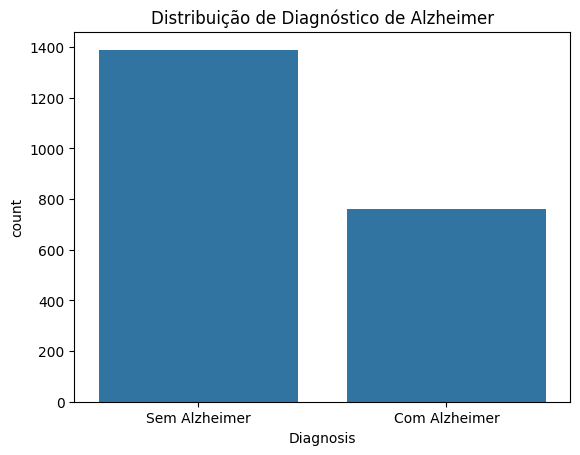

In [92]:
sns.countplot(x='Diagnosis', data=df_visual)
plt.title("Distribuição de Diagnóstico de Alzheimer")
plt.show()

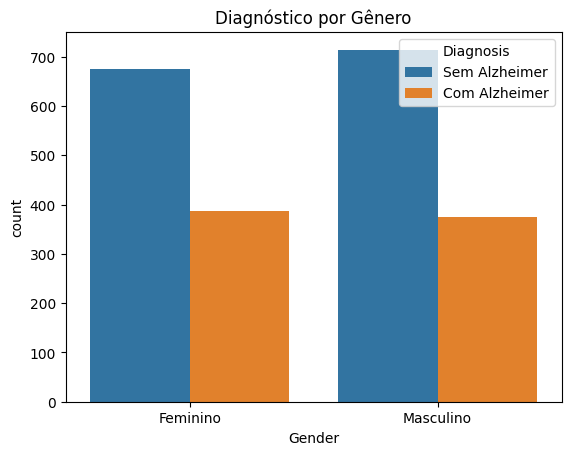

In [93]:
sns.countplot(x='Gender', hue='Diagnosis', data=df_visual)
plt.title("Diagnóstico por Gênero")
plt.show()

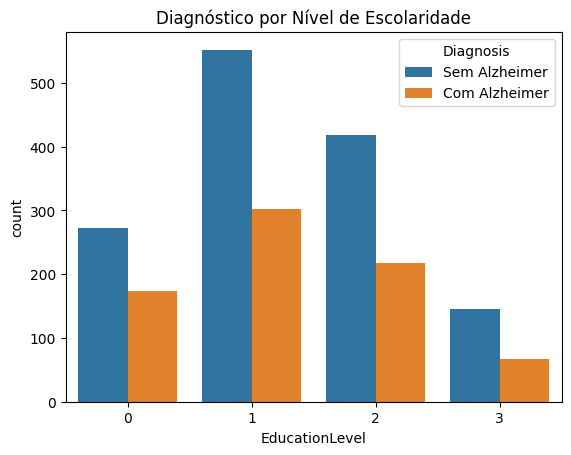

In [110]:
sns.countplot(x='EducationLevel', hue='Diagnosis', data=df_visual)
plt.title("Diagnóstico por Nível de Escolaridade")
plt.show()

## Distribuição das Variáveis

Aqui analisamos como os dados estão distribuídos, especialmente variáveis que podem indicar risco.

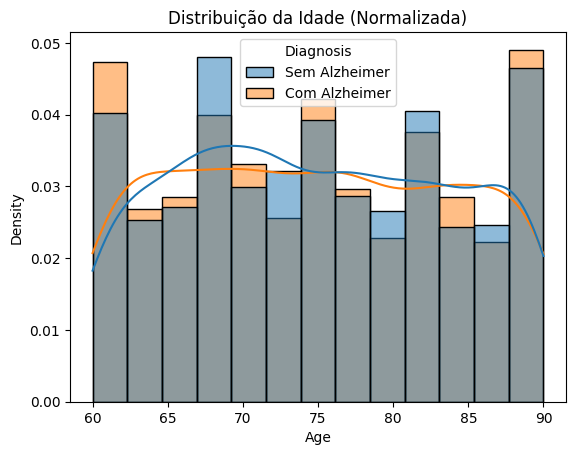

In [112]:
sns.histplot(
    data=df_visual,
    x='Age',
    hue='Diagnosis',
    kde=True,
    stat='density',
    common_norm=False,
    alpha=0.5
)

plt.title("Distribuição da Idade (Normalizada)")
plt.show()

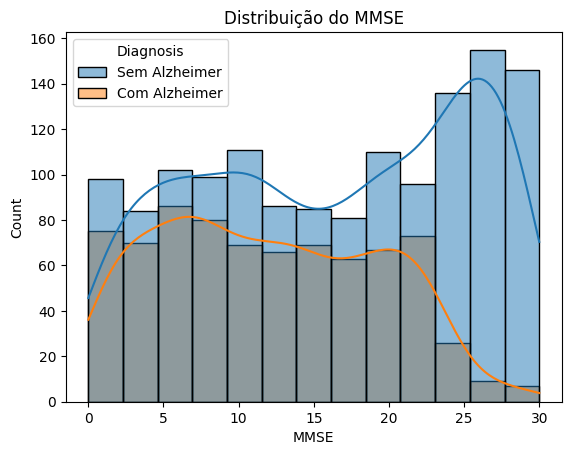

In [114]:
sns.histplot(data=df_visual, x='MMSE', hue='Diagnosis', kde=True) # MM
plt.title("Distribuição do MMSE")
plt.show()
# MMSE = Mini Mental State Examination

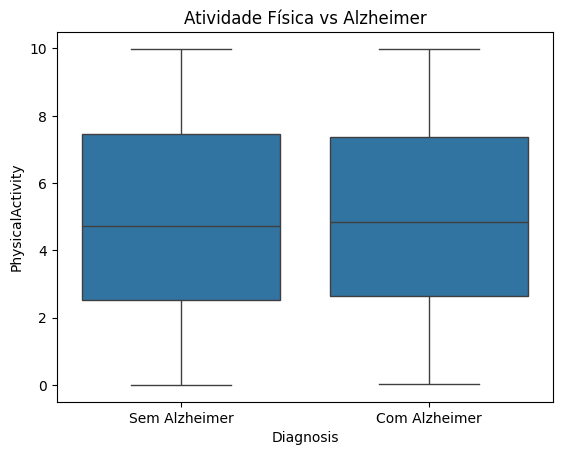

In [115]:
sns.boxplot(x='Diagnosis', y='PhysicalActivity', data=df_visual)
plt.title("Atividade Física vs Alzheimer")
plt.show()

## Correlação entre Variáveis

A matriz de correlação permite identificar relações importantes entre variáveis.

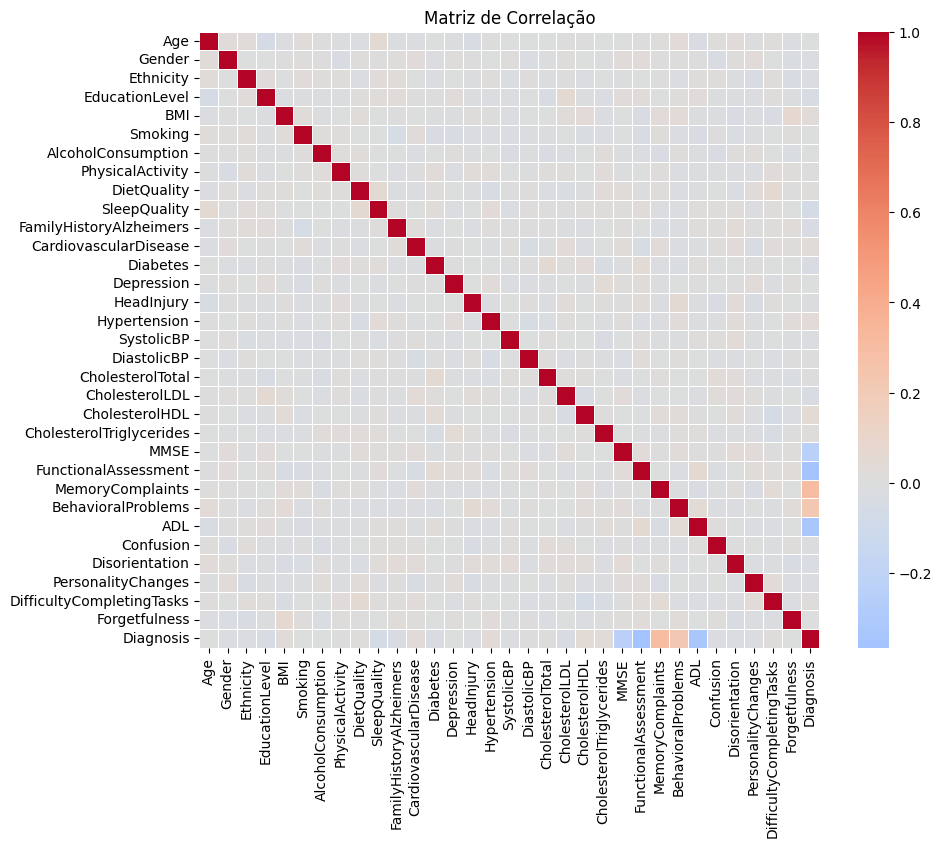

In [97]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_numeric.corr(),
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Matriz de Correlação")
plt.show()

## Variáveis mais correlacionadas com Diagnosis
Como visto na matriz anterior é calculado a correlação para criar uma nova matriz com as variáveis mais relevantes

In [98]:
# Calculando a correlação entre as variáveis numéricas
corr = df_numeric.corr()

# Correlação com Diagnosis
corr_target = corr['Diagnosis'].abs().sort_values(ascending=False)

# Selecionar top 8 (tirando o próprio Diagnosis)
top_vars = corr_target.index[1:9]

top_vars

Index(['FunctionalAssessment', 'ADL', 'MemoryComplaints', 'MMSE',
       'BehavioralProblems', 'SleepQuality', 'EducationLevel',
       'CholesterolHDL'],
      dtype='object')

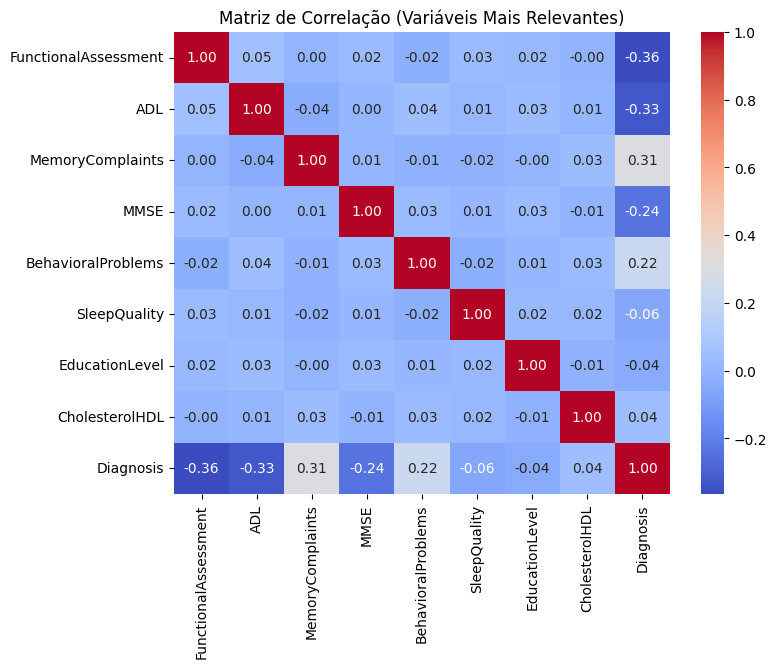

In [ ]:
# Criando uma nova matriz de correlação apenas com as variáveis mais relevantes
selected_vars = list(top_vars) + ['Diagnosis']

plt.figure(figsize=(8,6))
sns.heatmap(
    df_numeric[selected_vars].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Matriz de Correlação (Variáveis Mais Relevantes)")
plt.show()

## Correlação com a coluna que indique o diagnóstico de Alzheimer

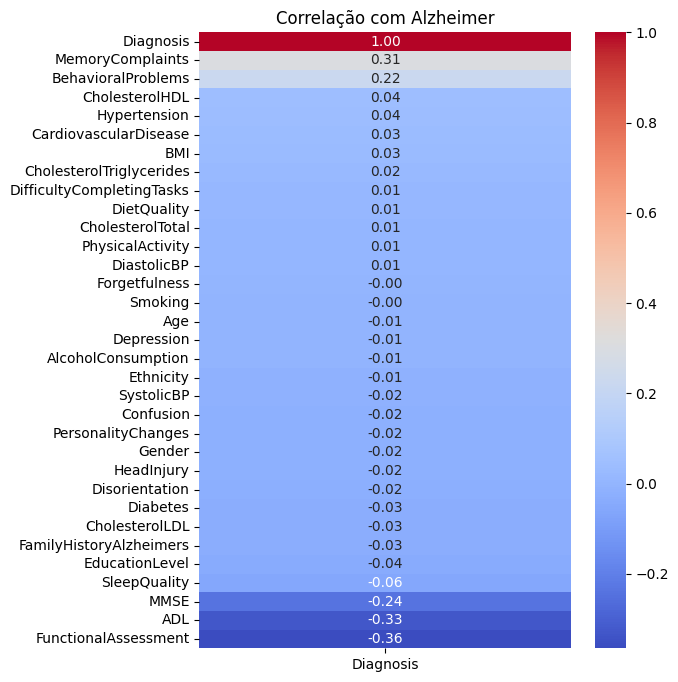

In [100]:
plt.figure(figsize=(6,8))
sns.heatmap(
    corr[['Diagnosis']].sort_values(by='Diagnosis', ascending=False),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlação com Alzheimer")
plt.show()

## Impacto do Estilo de Vida

Analisamos se hábitos influenciam o diagnóstico.

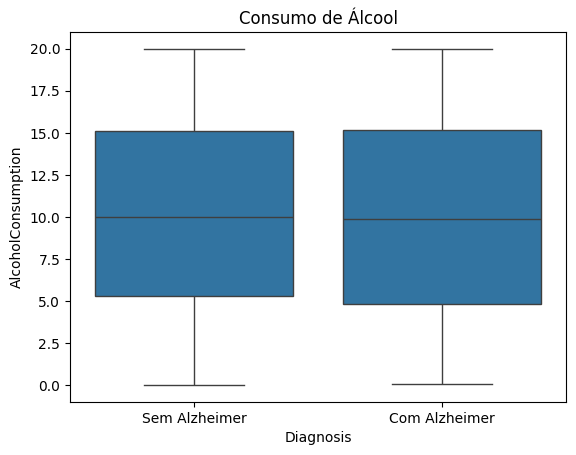

In [41]:
sns.boxplot(x='Diagnosis', y='AlcoholConsumption', data=df)
plt.title("Consumo de Álcool")
plt.show()

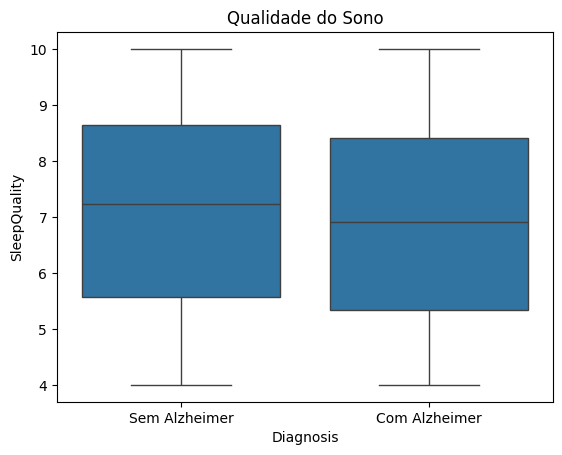

In [42]:
sns.boxplot(x='Diagnosis', y='SleepQuality', data=df)
plt.title("Qualidade do Sono")
plt.show()

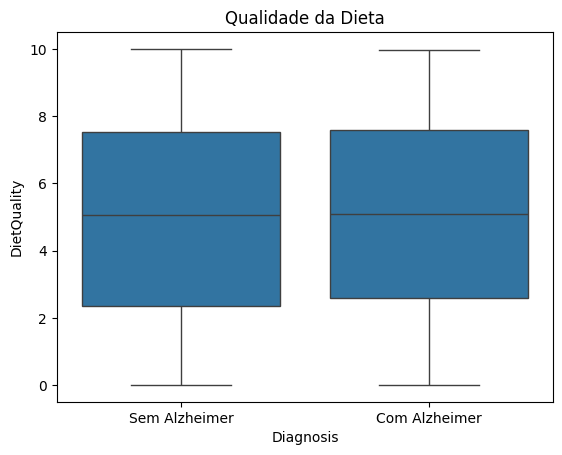

In [43]:
sns.boxplot(x='Diagnosis', y='DietQuality', data=df)
plt.title("Qualidade da Dieta")
plt.show()

## Condições Médicas

Avaliação da influência de doenças pré-existentes.

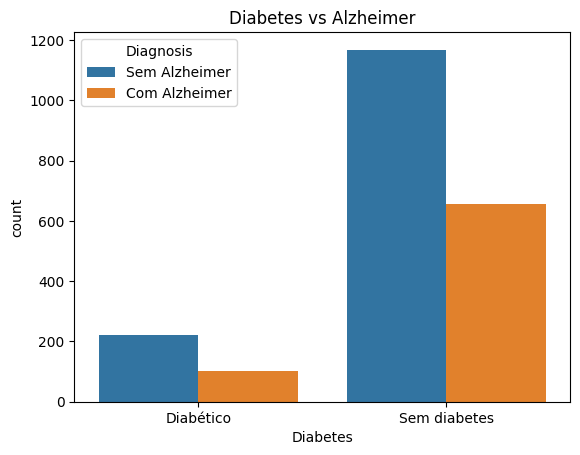

In [116]:
sns.countplot(x='Diabetes', hue='Diagnosis', data=df_visual)
plt.title("Diabetes vs Alzheimer")
plt.show()

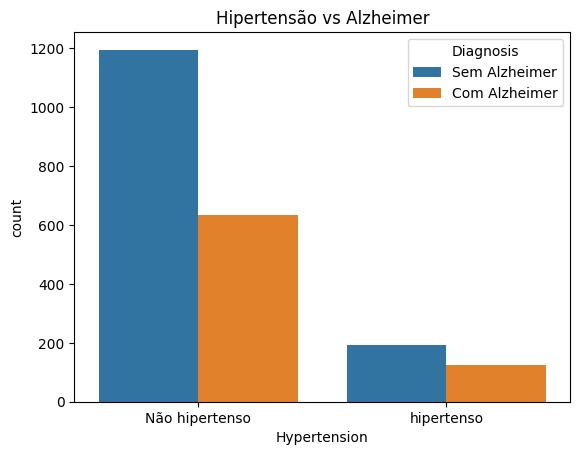

In [117]:

df['Hypertension'] = df['Hypertension'].map({0: 'Não', 1: 'Sim'})
sns.countplot(x='Hypertension', hue='Diagnosis', data=df_visual)
plt.title("Hipertensão vs Alzheimer")
plt.show()

## Sintomas Associados

Os sintomas apresentam forte relação com o diagnóstico.

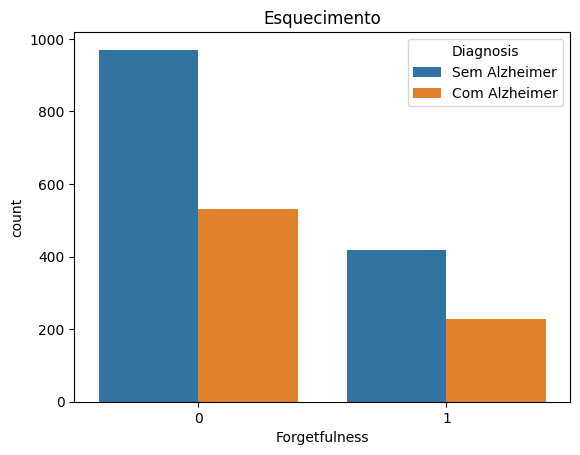

In [118]:
sns.countplot(x='Forgetfulness', hue='Diagnosis', data=df_visual)
plt.title("Esquecimento")
plt.show()

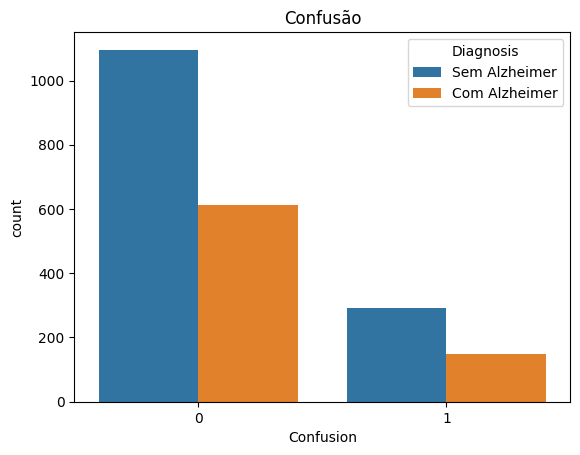

In [119]:
sns.countplot(x='Confusion', hue='Diagnosis', data=df_visual)
plt.title("Confusão")
plt.show()

## Parte II - Análise de casos
### Estudo de casos
- Caso 1 - Paciente com Alzheimer
- Caso 2 - Paciente sem Alzheimer
- Caso 3 - Caso intermediário


In [ ]:

# 1. SELEÇÃO DOS CASOS

# Caso 1 - Paciente com Alzheimer
caso1 = df[df['Diagnosis'] == 1].sample(1, random_state=42)

# Caso 2 - Paciente sem Alzheimer
caso2 = df[df['Diagnosis'] == 0].sample(1, random_state=42)

# Caso 3 - Caso intermediário (MMSE médio)
caso3 = df[(df['MMSE'] > 18) & (df['MMSE'] < 24)].sample(1, random_state=42)


In [108]:

casos = pd.concat([caso1, caso2, caso3])
casos.index = ['Caso 1 (Alzheimer)', 'Caso 2 (Sem Alzheimer)', 'Caso 3 (Intermediário)']

casos[['Age', 'MMSE', 'ADL', 'MemoryComplaints', 'BehavioralProblems', 'Diagnosis']]

,Age,MMSE,ADL,MemoryComplaints,BehavioralProblems,Diagnosis
Caso 1 (Alzheimer),63,14.415137,2.189451,1,0,1
Caso 2 (Sem Alzheimer),71,9.168286,3.905473,0,0,0
Caso 3 (Intermediário),66,18.385040,8.923831,0,0,0
